In [1]:
from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from keras.applications.resnet50 import ResNet50

# from keras.application.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image  import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders

2024-02-19 10:43:34.297278: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-19 10:43:34.372456: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-19 10:43:34.372502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-19 10:43:34.374310: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-19 10:43:34.385421: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-19 10:43:34.386039: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
IMAGE_SIZE = [224, 224]
data = tf.keras.utils.image_dataset_from_directory('./DataSet/Segmented Medicinal Leaf Images/')

Found 1835 files belonging to 30 classes.


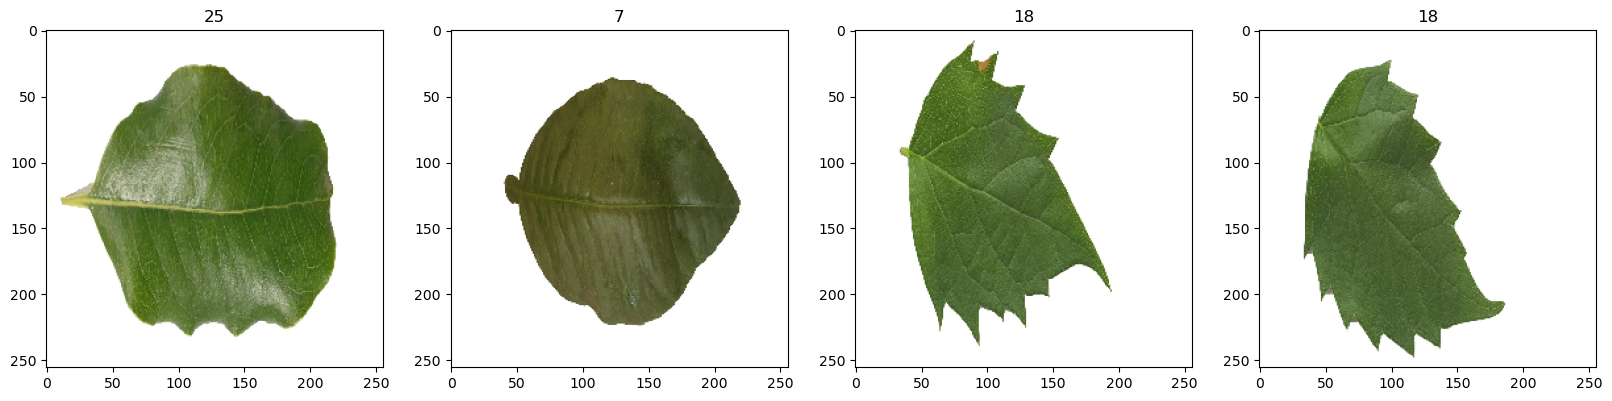

In [3]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [4]:
data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()

(array([[[[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         ...,
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.]]],
 
 
        [

In [5]:
train_size = int( len(data) * 0.7 )

val_size = int(len( data) * 0.2 ) 

test_size = int(len( data) * 0.1)

In [6]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [7]:
resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [8]:
for layer in resnet.layers:
    layer.trainable = False

In [9]:
splitfolders.ratio("./DataSet/Segmented Medicinal Leaf Images/",
                   output="./Dataset", seed=1337, ratio=(.8,.1,.1), group_prefix=None)

Copying files: 1835 files [00:01, 959.96 files/s]


In [10]:
train_path="./Dataset/train"
test_path = './Dataset/test'

In [11]:
folders = glob('./Dataset/train/*')

In [12]:
x = Flatten()(resnet.output)

In [13]:
prediction = Dense(len(folders), activation="softmax")(x)
model = Model(inputs=resnet.input, outputs = prediction)

In [14]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

                                                                                                  
 conv2_block3_1_conv (Conv2  (None, 56, 56, 64)           16448     ['conv2_block2_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv2_block3_1_bn (BatchNo  (None, 56, 56, 64)           256       ['conv2_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv2_block3_1_relu (Activ  (None, 56, 56, 64)           0         ['conv2_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv2_blo

 ation)                                                                                           
                                                                                                  
 conv3_block2_3_conv (Conv2  (None, 28, 28, 512)          66048     ['conv3_block2_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv3_block2_3_bn (BatchNo  (None, 28, 28, 512)          2048      ['conv3_block2_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv3_block2_add (Add)      (None, 28, 28, 512)          0         ['conv3_block1_out[0][0]',    
                                                                     'conv3_block2_3_bn[0][0]']   
          

 conv4_block1_2_conv (Conv2  (None, 14, 14, 256)          590080    ['conv4_block1_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block1_2_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block1_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block1_2_relu (Activ  (None, 14, 14, 256)          0         ['conv4_block1_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block1_0_conv (Conv2  (None, 14, 14, 1024)         525312    ['conv3_block4_out[0][0]']    
 D)       

                                                                                                  
 conv4_block3_out (Activati  (None, 14, 14, 1024)         0         ['conv4_block3_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv4_block4_1_conv (Conv2  (None, 14, 14, 256)          262400    ['conv4_block3_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv4_block4_1_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block4_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_blo

 D)                                                                                               
                                                                                                  
 conv4_block6_3_bn (BatchNo  (None, 14, 14, 1024)         4096      ['conv4_block6_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block6_add (Add)      (None, 14, 14, 1024)         0         ['conv4_block5_out[0][0]',    
                                                                     'conv4_block6_3_bn[0][0]']   
                                                                                                  
 conv4_block6_out (Activati  (None, 14, 14, 1024)         0         ['conv4_block6_add[0][0]']    
 on)                                                                                              
          

 conv5_block3_1_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv5_block3_2_conv (Conv2  (None, 7, 7, 512)            2359808   ['conv5_block3_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv5_block3_2_bn (BatchNo  (None, 7, 7, 512)            2048      ['conv5_block3_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block3_2_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block3_2_bn[0][0]']   
 ation)   

In [15]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [16]:
from keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                                              shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True
                                  )
test_datagen = ImageDataGenerator(rescale = 1./255)

In [17]:
training_set = train_datagen.flow_from_directory("Dataset/train",target_size = (224, 224),
                                                                               batch_size = 32,
                                                 class_mode = "categorical")

Found 1455 images belonging to 30 classes.


In [18]:
test_set = test_datagen.flow_from_directory('Dataset/test', target_size=(224,224), batch_size = 32,
                                            class_mode = 'categorical')

Found 209 images belonging to 30 classes.


In [19]:
r = model.fit(
    training_set,
    validation_data=test_set,
    epochs=20,
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)

Epoch 1/20


2024-02-19 10:43:59.106271: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2024-02-19 10:43:59.242953: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2024-02-19 10:43:59.297042: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 106463232 exceeds 10% of free system memory.
2024-02-19 10:43:59.361572: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2024-02-19 10:43:59.421972: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.


46/46 [==============================] - 167s 3s/step - loss: 11.8684 - accuracy: 0.1430 - val_loss: 4.4436 - val_accuracy: 0.3158
Epoch 2/20
46/46 [==============================] - 164s 4s/step - loss: 3.1814 - accuracy: 0.3113 - val_loss: 2.0150 - val_accuracy: 0.4211
Epoch 3/20
46/46 [==============================] - 164s 4s/step - loss: 2.4777 - accuracy: 0.4151 - val_loss: 3.1506 - val_accuracy: 0.3971
Epoch 4/20
46/46 [==============================] - 151s 3s/step - loss: 2.6048 - accuracy: 0.4172 - val_loss: 2.6306 - val_accuracy: 0.4833
Epoch 5/20
46/46 [==============================] - 183s 4s/step - loss: 1.9398 - accuracy: 0.5285 - val_loss: 2.5834 - val_accuracy: 0.5407
Epoch 6/20
46/46 [==============================] - 185s 4s/step - loss: 2.4599 - accuracy: 0.4708 - val_loss: 2.0779 - val_accuracy: 0.5120
Epoch 7/20
46/46 [==============================] - 151s 3s/step - loss: 2.1539 - accuracy: 0.5278 - val_loss: 2.3184 - val_accuracy: 0.5598
Epoch 8/20
46/46 [=====

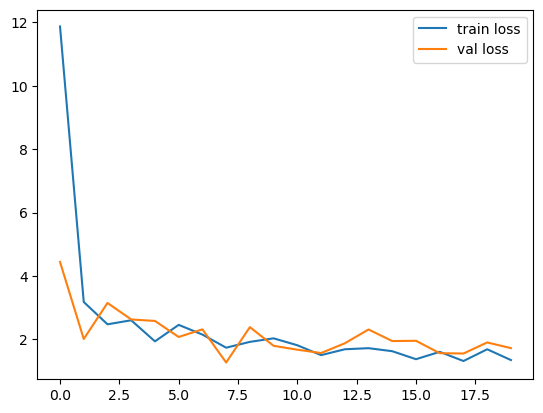

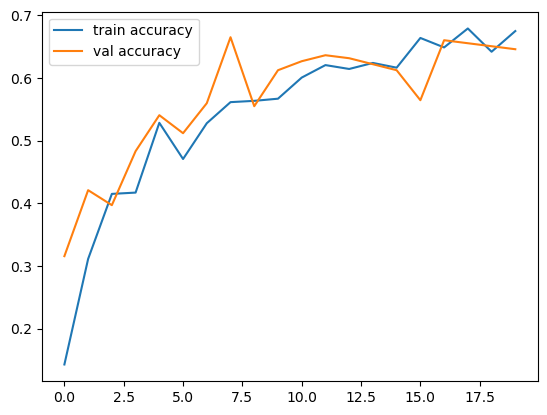

<Figure size 640x480 with 0 Axes>

In [20]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()
plt.savefig("AccVal_accuracy")

In [21]:
from keras.models import load_model
model.save('./model_resnet50.h5')

/home/dhinesh/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


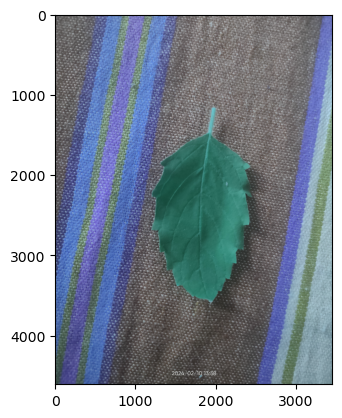

In [22]:
import cv2
img = cv2.imread('test1.jpg')
plt.imshow(img)
plt.show()

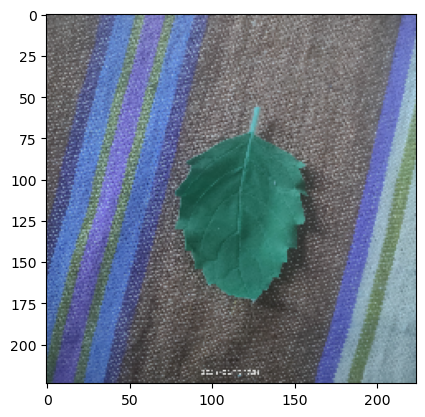

In [23]:
resize = tf.image.resize(img, (224, 224))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [24]:
yhat = model.predict(np.expand_dims(resize/255,0))
print(yhat[0][0])

1/1 [==============================] - 2s 2s/step
0.0346107


In [25]:
if yhat[0][0] > 0.5:
    print(f'Yes working')
else:
    print(f'No, its not Workingi')

No, its not Workingi


In [26]:
model = load_model('./model_resnet50.h5')
s=model.predict(np.expand_dims(resize/255,0))
print(s[0][0])

1/1 [==============================] - 2s 2s/step
0.0346107


In [27]:
from tensorflow.keras.models import load_model
model = load_model("./model_resnet50.h5")

In [29]:
import tensorflow as tf
import numpy as np
import os
def classify_plant_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    
    class_names = sorted(os.listdir(train_path))
    predicted_class_name = class_names[predicted_class]
    
    return predicted_class_name

# Example usage
image_path = 'test2.jpg'
predicted_class = classify_plant_image(image_path)
print(f'Predicted Class: {predicted_class}')

1/1 [==============================] - 0s 113ms/step
Predicted Class: Citrus Limon (Lemon)
